# Customer Feedback Analytics System
## Module 1: Data Cleaning & CSI Calculation

**Source:** Amazon India Sales & Customer Reviews Dataset

This notebook loads the raw product/review dataset, cleans it (parses currency
fields, fixes corrupted values, removes duplicates), and calculates a
Customer Satisfaction Index (CSI) per product, category, and price tier.

In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)

## Part 1: Load Raw Data

In [14]:
df = pd.read_csv("data/raw/amazon_raw.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Comp...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹399,"₹1,099",64%,4.2,"24,269","High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 P...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S....","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1KD19VHEDV0OR,R3C02RMYQMK6FC,R39...","Satisfied,Charging is really fast,Value for money,Product review,Good qualit...","Looks durable Charging is fine tooNo complains,Charging is really fast, good...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/51UsScvHQNL._SX3...,https://www.amazon.in/Wayona-Braided-WN3LG1-Syncing-Charging/dp/B07JW9H4J1/r...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Sma...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be it an android smartphone (Mi,...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBXNGXZJT525AQ,AHONIZU3ICIEHQIGQ6...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Placeholder,BharanI,sonia,Niam","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RYGGS0M09S3KY,R17KQRUTAN5DKS,R3A...","A Good Braided Cable for Your Type C Device,Good quality product from ambran...",I ordered this cable to connect my phone to Android Auto of car. The cable i...,https://m.media-amazon.com/images/W/WEBP_402378-T2/images/I/31zOsqQOAOL._SY4...,https://www.amazon.in/Ambrane-Unbreakable-Charging-Braided-Cable/dp/B098NS6P...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safety proctections and four-core c...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQLWQOWZ4N3OA,AHTPQRIMGUD4BYR5YI...","Kunal,Himanshu,viswanath,sai niharka,saqib malik,Aashiq,Ramu Challa,Sanjay g...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R25X4TBMPY91LX,R27OK7G99VK0TR,R2...","Good speed for earlier versions,Good Product,Working good,Good for the price...","Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/31IvNJZnmdL._SY4...,https://www.amazon.in/Sounce-iPhone-Charging-Compatible-Devices/dp/B096MSW6C...


## Part 2: Initial Data Quality Check
Before cleaning, we inspect the raw data for corrupted values, missing data,
and duplicate records.

In [15]:
bad_rating_mask = pd.to_numeric(df["rating"], errors="coerce").isna()
print("Corrupted rating rows:", bad_rating_mask.sum())
print(df[bad_rating_mask][["product_id", "rating"]])

print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate product_id count:", df["product_id"].duplicated().sum())

Corrupted rating rows: 1
      product_id rating
1279  B08L12N5H1      |

Missing values per column:
rating_count    2
dtype: int64

Duplicate product_id count: 114


## Part 3: Cleaning

1. Parse currency (₹) and percentage (%) strings into numeric fields
2. Remove the corrupted rating record
3. Fill missing `rating_count` with median
4. Remove duplicate `product_id` entries
5. Clean and combine review text fields
6. Derive category and price-tier fields for segmentation

In [16]:
def parse_currency(x):
    if pd.isna(x):
        return np.nan
    x = re.sub(r"[₹,]", "", str(x)).strip()
    try:
        return float(x)
    except ValueError:
        return np.nan

def parse_percentage(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("%", "").strip()
    try:
        return float(x)
    except ValueError:
        return np.nan

def parse_rating_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace(",", "").strip()
    try:
        return int(float(x))
    except ValueError:
        return np.nan

In [17]:
n_raw = len(df)

df["discounted_price"] = df["discounted_price"].apply(parse_currency)
df["actual_price"] = df["actual_price"].apply(parse_currency)
df["discount_percentage"] = df["discount_percentage"].apply(parse_percentage)
df["rating_count"] = df["rating_count"].apply(parse_rating_count)

df = df[~pd.to_numeric(df["rating"], errors="coerce").isna()].copy()
df["rating"] = df["rating"].astype(float)

df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

n_dupes = df["product_id"].duplicated().sum()
df = df.drop_duplicates(subset="product_id", keep="first").copy()

for col in ["review_title", "review_content", "product_name"]:
    df[col] = df[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

df["main_category"] = df["category"].str.split("|").str[0]
df["sub_category"] = df["category"].str.split("|").str[1]

df["review_text_full"] = (df["review_title"] + ". " + df["review_content"]).str.strip()

df["price_tier"] = pd.cut(
    df["discounted_price"],
    bins=[0, 500, 1500, 5000, np.inf],
    labels=["Budget (<500)", "Mid (500-1500)", "Premium (1500-5000)", "Luxury (5000+)"]
)

print(f"Raw records: {n_raw}")
print(f"Duplicates removed: {n_dupes}")
print(f"Final cleaned records: {len(df)}")
df.head(3)

Raw records: 1465
Duplicates removed: 114
Final cleaned records: 1350


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category,sub_category,review_text_full,price_tier
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Comp...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,399.0,1099.0,64.0,4.2,24269.0,"High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 P...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S....","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1KD19VHEDV0OR,R3C02RMYQMK6FC,R39...","Satisfied,Charging is really fast,Value for money,Product review,Good qualit...","Looks durable Charging is fine tooNo complains,Charging is really fast, good...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/51UsScvHQNL._SX3...,https://www.amazon.in/Wayona-Braided-WN3LG1-Syncing-Charging/dp/B07JW9H4J1/r...,Computers&Accessories,Accessories&Peripherals,"Satisfied,Charging is really fast,Value for money,Product review,Good qualit...",Budget (<500)
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Sma...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be it an android smartphone (Mi,...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBXNGXZJT525AQ,AHONIZU3ICIEHQIGQ6...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Placeholder,BharanI,sonia,Niam","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RYGGS0M09S3KY,R17KQRUTAN5DKS,R3A...","A Good Braided Cable for Your Type C Device,Good quality product from ambran...",I ordered this cable to connect my phone to Android Auto of car. The cable i...,https://m.media-amazon.com/images/W/WEBP_402378-T2/images/I/31zOsqQOAOL._SY4...,https://www.amazon.in/Ambrane-Unbreakable-Charging-Braided-Cable/dp/B098NS6P...,Computers&Accessories,Accessories&Peripherals,"A Good Braided Cable for Your Type C Device,Good quality product from ambran...",Budget (<500)
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safety proctections and four-core c...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQLWQOWZ4N3OA,AHTPQRIMGUD4BYR5YI...","Kunal,Himanshu,viswanath,sai niharka,saqib malik,Aashiq,Ramu Challa,Sanjay g...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R25X4TBMPY91LX,R27OK7G99VK0TR,R2...","Good speed for earlier versions,Good Product,Working good,Good for the price...","Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/31IvNJZnmdL._SY4...,https://www.amazon.in/Sounce-iPhone-Charging-Compatible-Devices/dp/B096MSW6C...,Computers&Accessories,Accessories&Peripherals,"Good speed for earlier versions,Good Product,Working good,Good for the price...",Budget (<500)


## Part 4: Save Cleaned Dataset

In [18]:
final_cols = [
    "product_id", "product_name", "main_category", "sub_category",
    "discounted_price", "actual_price", "discount_percentage",
    "rating", "rating_count", "price_tier",
    "review_title", "review_content", "review_text_full"
]
df_final = df[final_cols].reset_index(drop=True)
df_final.to_csv("data/cleaned_feedback_data.csv", index=False)
print("Saved cleaned_feedback_data.csv:", df_final.shape)

Saved cleaned_feedback_data.csv: (1350, 13)


## Part 5: Customer Satisfaction Index (CSI) Calculation

**Methodology:**
- Base CSI = (rating / 5) × 100 — converts the 5-point scale to a 0–100 index
- Bayesian-weighted rating (IMDb-style) to prevent low-review-count products
  from skewing results: v/(v+m)·R + m/(v+m)·C
- Products banded into Highly Satisfied / Satisfied / Neutral / Dissatisfied

In [19]:
df_final["csi_score"] = (df_final["rating"] / 5.0) * 100

C = df_final["rating"].mean()
m = df_final["rating_count"].median()
v = df_final["rating_count"]
R = df_final["rating"]
df_final["weighted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C
df_final["weighted_csi_score"] = (df_final["weighted_rating"] / 5.0) * 100

def satisfaction_band(csi):
    if csi >= 80: return "Highly Satisfied"
    elif csi >= 60: return "Satisfied"
    elif csi >= 40: return "Neutral"
    else: return "Dissatisfied"

df_final["satisfaction_band"] = df_final["csi_score"].apply(satisfaction_band)

df_final.to_csv("data/csi_by_product.csv", index=False)

overall_csi_simple = df_final["csi_score"].mean()
overall_csi_weighted = np.average(df_final["csi_score"], weights=df_final["rating_count"])

print(f"Overall CSI (simple): {overall_csi_simple:.2f}")
print(f"Overall CSI (weighted): {overall_csi_weighted:.2f}")
print("\nSatisfaction band distribution:")
df_final["satisfaction_band"].value_counts()

Overall CSI (simple): 81.84
Overall CSI (weighted): 83.21

Satisfaction band distribution:


satisfaction_band
Highly Satisfied    1010
Satisfied            334
Neutral                6
Name: count, dtype: int64

## Part 6: CSI by Category

In [20]:
cat_summary = df_final.groupby("main_category").agg(
    n_products=("product_id", "count"),
    avg_rating=("rating", "mean"),
    csi_score=("csi_score", "mean"),
    weighted_csi_score=("weighted_csi_score", "mean"),
    total_reviews=("rating_count", "sum"),
).sort_values("csi_score", ascending=False).reset_index()

cat_summary.to_csv("data/csi_by_category.csv", index=False)
cat_summary

,main_category,n_products,avg_rating,csi_score,weighted_csi_score,total_reviews
0,OfficeProducts,31,4.309677,86.193548,83.944494,149675.0
1,Toys&Games,1,4.300000,86.000000,85.042129,15867.0
2,HomeImprovement,2,4.250000,85.000000,83.790517,8566.0
3,Computers&Accessories,375,4.153867,83.077333,82.756963,6345535.0
4,Electronics,490,4.077755,81.555102,82.096480,14208406.0
5,Home&Kitchen,447,4.040716,80.814318,81.889389,2990077.0
6,Health&PersonalCare,1,4.000000,80.000000,81.036434,3663.0
7,MusicalInstruments,2,3.900000,78.000000,78.613808,88882.0
8,Car&Motorbike,1,3.800000,76.000000,80.723418,1118.0


## Part 7: CSI by Price Tier

In [21]:
tier_summary = df_final.groupby("price_tier", observed=True).agg(
    n_products=("product_id", "count"),
    avg_rating=("rating", "mean"),
    csi_score=("csi_score", "mean"),
    weighted_csi_score=("weighted_csi_score", "mean"),
).reset_index()

tier_summary.to_csv("data/csi_by_price_tier.csv", index=False)
tier_summary

,price_tier,n_products,avg_rating,csi_score,weighted_csi_score
0,Budget (<500),501,4.069062,81.381238,82.116561
1,Mid (500-1500),400,4.083500,81.670000,82.294996
2,Premium (1500-5000),246,4.085772,81.715447,82.057474
3,Luxury (5000+),203,4.171921,83.438424,82.734229


## Part 8: Visualization

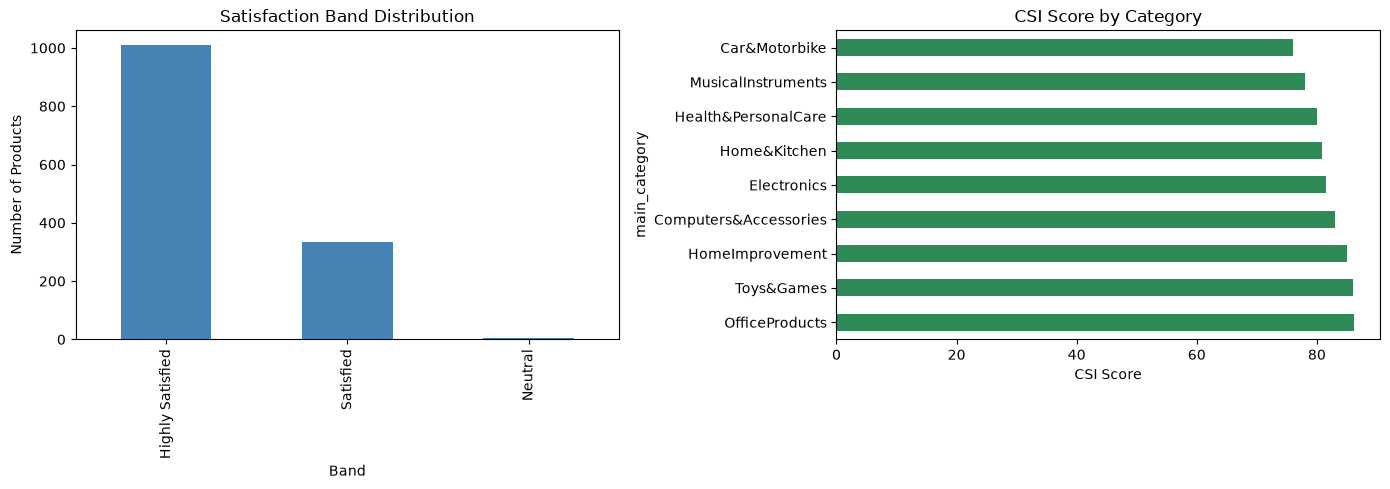

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_final["satisfaction_band"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Satisfaction Band Distribution")
axes[0].set_xlabel("Band")
axes[0].set_ylabel("Number of Products")

cat_summary.set_index("main_category")["csi_score"].plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("CSI Score by Category")
axes[1].set_xlabel("CSI Score")

plt.tight_layout()
plt.savefig("data/csi_charts.png", dpi=150)
plt.show()